# 4. Inference using GRACE data for an ice load

## Setup

We begin by importing the necessary components from `pyslfp`, `pygeoinf`, and other standard libraries. We will also initialize our `FingerPrint` model, which provides the underlying physics.

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pyslfp as sl
import pygeoinf as inf
import cartopy.crs as ccrs
from pygeoinf.plot import plot_1d_distributions, plot_corner_distributions
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from pathlib import Path

fig_format = "png"
NOTEBOOK_DIR = Path.cwd()
FIGURES_DIR = NOTEBOOK_DIR.parent / "figures" / fig_format
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Notebook directory: /home/david/dev/pyslfp/work
Figures will be saved to: /home/david/dev/pyslfp/figures/png


In [20]:
# --- Create the fingerprint object and set the background ice state ---
lmax = 64
fp = sl.FingerPrint(
    lmax=lmax,
    earth_model_parameters=sl.EarthModelParameters.from_standard_non_dimensionalisation(),
)
fp.set_state_from_ice_ng()

#===============================================================
# Create the forward operator for the inference problem, which 
# maps from unknown ice thickness change to GRACE observations.
#===============================================================

# --- Model space ---
order = 2.0
scale_km = 500.0
scale = scale_km * 1000 / fp.length_scale
model_space = inf.symmetric_space.sphere.Sobolev(
    fp.lmax, order, scale, radius=fp.mean_sea_floor_radius
)

# --- Ice projection operator ---
# Maps scalar fields to be non-zero over the ice sheets only, and then converts to a load 
ice_mask_operator = sl.ice_projection_operator(fp, model_space)
ice_thickness_to_load_operator = sl.ice_thickness_change_to_load_operator(fp, model_space)
ice_projection_forward_operator = ice_thickness_to_load_operator @ ice_mask_operator

# --- Fingerprint operator ---
# Maps a direct load to the full response
fingerprint_operator = fp.as_sobolev_linear_operator(order, scale, rtol=1e-9)

# --- Observation operator: GRACE Observations ---
# observation_degree is the truncation degree for the spherical harmonic coefficient observations
observation_degree = 40
grace_operator = sl.operators.grace_operator(fingerprint_operator.codomain, observation_degree)

# --- Form the forward operator by composition --- 
forward_operator = grace_operator @ fingerprint_operator @ ice_projection_forward_operator
data_space = forward_operator.codomain

# --- Form also a mapping from the model space to the sea level field for convenience ---
P = fingerprint_operator.codomain.subspace_projection(0)
model_space_to_sl_operator = P @ fingerprint_operator @ ice_projection_forward_operator

In [21]:
# --- Set the initial model prior measure ---
pointwise_std_m = 0.1
pointwise_std = pointwise_std_m / fp.length_scale
initial_model_prior_measure = model_space.point_value_scaled_heat_kernel_gaussian_measure(scale, std=pointwise_std)

# --- Transform so that ice thickness change is non-zero only over current ice ---    
model_prior_measure = initial_model_prior_measure.affine_mapping(operator=ice_mask_operator)

In [22]:
from pygeoinf.auxiliary import empirical_data_error_measure

# --- Define a prior with a smaller length scale (rougher)
noise_model_prior_measure = model_space.point_value_scaled_sobolev_kernel_gaussian_measure(order, scale, std=pointwise_std)

# --- Define a generic, non-ice-specific forward operator
forward_operator_no_mask = grace_operator @ fingerprint_operator @ ice_thickness_to_load_operator

heuristic_data_error_measure = empirical_data_error_measure(noise_model_prior_measure, forward_operator_no_mask, scale_factor=0.1)
diags = np.linalg.diagonal(heuristic_data_error_measure.covariance.matrix(dense=True))

data_error_measure = inf.GaussianMeasure.from_standard_deviations(data_space, diags)

# --- Bundle everything into a forward problem object ---
forward_problem = inf.LinearForwardProblem(
    forward_operator, data_error_measure=data_error_measure
)

print(f'Forward problem: {model_space.dim} -> {grace_operator.codomain.dim}')

Forward problem: 4225 -> 1677


In [23]:
# --- Generate synthetic ground truth and noisy data --- 83
#np.random.seed(94)
model_true, data = forward_problem.synthetic_model_and_data(model_prior_measure)

print(f"Generated synthetic data:")
print(f"  GRACE data: {len(data)} spherical harmonic coefficients")

Generated synthetic data:
  GRACE data: 1677 spherical harmonic coefficients


In [24]:
# --- Set to true if you want to use preconditioning ---
use_preconditioning = False

if use_preconditioning:
    # Repeat the set up of the forward problem, but now using a lower lmax
    lmax_precon = 32
    fp_precon = sl.FingerPrint(
        lmax=lmax_precon,
        earth_model_parameters=sl.EarthModelParameters.from_standard_non_dimensionalisation(),
    )
    fp_precon.set_state_from_ice_ng()

    model_space_precon = inf.symmetric_space.sphere.Sobolev(
        fp_precon.lmax, order, scale, radius=fp_precon.mean_sea_floor_radius
    )
    # Ice projection operator at lower resolution
    op1_precon = sl.ice_projection_operator(fp_precon, model_space_precon)
    op2_precon = sl.ice_thickness_change_to_load_operator(fp_precon, model_space_precon)
    ice_projection_forward_operator_precon = op2_precon @ op1_precon

    # Fingerprint operator at lower resolution
    fingerprint_operator_precon = fp_precon.as_sobolev_linear_operator(order, scale, rtol=1e-9)

    # GRACE problem at lower resolution
    grace_operator_precon = sl.operators.grace_operator(fingerprint_operator_precon.codomain, observation_degree)

    # Forward problem at lower resolution
    forward_operator_precon = grace_operator_precon @ fingerprint_operator_precon @ ice_projection_forward_operator_precon

    # Form the forward problem at lower resolution
    forward_problem_precon = inf.LinearForwardProblem(forward_operator_precon, data_error_measure=data_error_measure)

    # Prior at lower resolution
    initial_model_prior_measure_precon = model_space_precon.point_value_scaled_heat_kernel_gaussian_measure(scale,std= pointwise_std)
    model_prior_measure_precon = initial_model_prior_measure_precon.affine_mapping(operator=op1_precon)

Having formed the reduced-degree problem, we can set up the necessary Bayesian inverse problems, extract the approximate normal operator for preconditioning, and then solve the full problem iteratively. Note that running this calculation at degree 256 will still take several minutes, but without preconditioning this would be substantially greater. 

In [ ]:
# --- Set up the preconditioner if necessary ---
if use_preconditioning:
    bayesian_inversion_precon = inf.LinearBayesianInversion(forward_problem_precon, model_prior_measure_precon)
    normal_operator_precon = bayesian_inversion_precon.normal_operator
    solver = inf.EigenSolver(parallel=True, n_jobs=8)
    inverse_normal_operator_precon = solver(normal_operator_precon)
else:
    inverse_normal_operator_precon = None

# --- Set up the Bayesian inversion ---
bayesian_inversion = inf.LinearBayesianInversion(forward_problem, model_prior_measure)

# --- Solve for the posterior distribution ---
print("Solving the linear system...")
#model_posterior_measure = bayesian_inversion.model_posterior_measure(
#    data, inf.CGMatrixSolver(), preconditioner=inverse_normal_operator_precon
#)

model_posterior_measure = bayesian_inversion.model_posterior_measure(
    data, inf.EigenSolver()
)

# --- Get the posterior expectation ---
model_posterior_expectation = model_posterior_measure.expectation

# --- Print out the total number of calls to the fingerpint solver - one will be for generating the synthetic data ---
print(f'Number of solutions of the fingerprint problem = {fp.solver_counter}')
print("Inversion completed successfully!")

Solving the linear system...


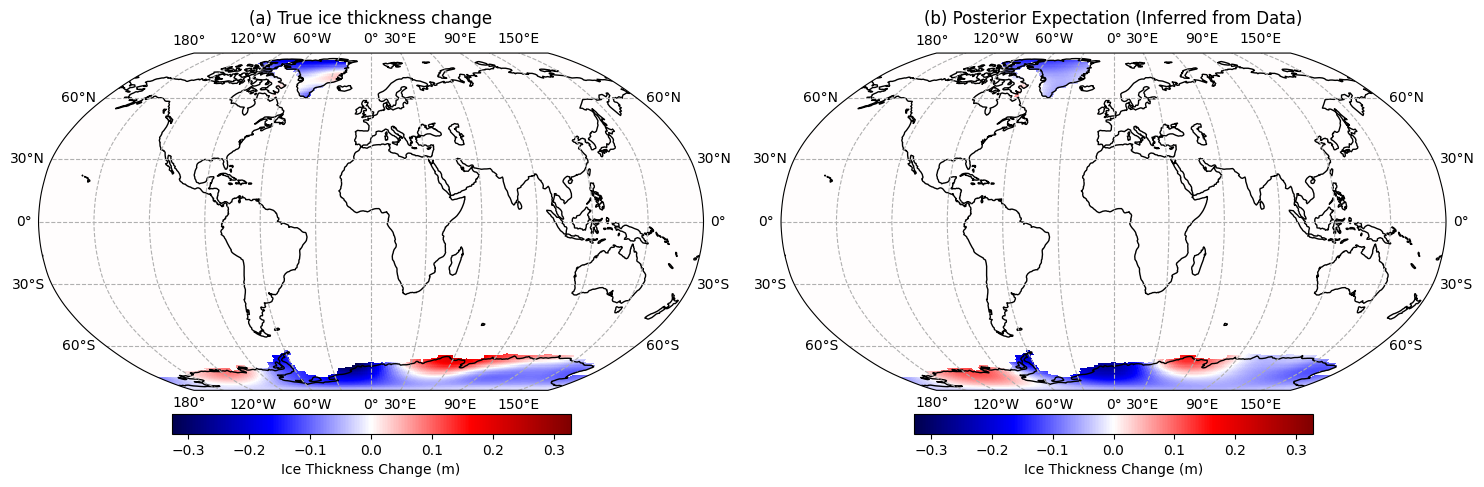

In [ ]:
# --- Calculate a shared, symmetric color scale for the ice thickness plots ---
max_abs_ice_change = np.nanmax(
    np.abs(
        np.concatenate([
            (model_true).data.flatten(),
            (model_posterior_expectation).data.flatten()
        ])
    )
) * fp.length_scale

# --- Create a 1x2 subplot layout ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), 
                        subplot_kw={'projection': ccrs.Robinson()})

# --- Prepare the data for each subplot ---
datasets = [model_true * fp.length_scale, model_posterior_expectation * fp.length_scale]
titles = ['(a) True ice thickness change', '(b) Posterior Expectation (Inferred from Data)']

for i, (dataset, title) in enumerate(zip(datasets, titles)):
    ax = axes[i]
    
    lons, lats = dataset.lons(), dataset.lats()
    kwargs = {'transform': ccrs.PlateCarree(), 'cmap': 'seismic', 
              'vmin': -max_abs_ice_change, 'vmax': max_abs_ice_change}
    
    im = ax.pcolormesh(lons, lats, dataset.data, **kwargs)
    ax.coastlines()
    ax.set_title(title)

    # Tick marks and labels
    lat_interval = kwargs.pop("lat_interval", 30)
    lon_interval = kwargs.pop("lon_interval", 30)
    gl = ax.gridlines(
        linestyle="--",
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
    )
    gl.xlocator = mticker.MultipleLocator(lon_interval)
    gl.ylocator = mticker.MultipleLocator(lat_interval)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    
    # Add colorbar below each subplot
    plt.colorbar(im, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05, 
                 label='Ice Thickness Change (m)')

plt.tight_layout()

plt.savefig(FIGURES_DIR / f"4-1_GRACE_inference_ice.{fig_format}", dpi=300, bbox_inches='tight')

### Plotting the Predicted Sea Level

As a final check, we can use our inferred ice melt pattern (`model_posterior_expectation`) to predict the global sea-level fingerprint. By comparing this predicted fingerprint to the "true" fingerprint, we can visually assess how well our inversion has captured the large-scale signal.

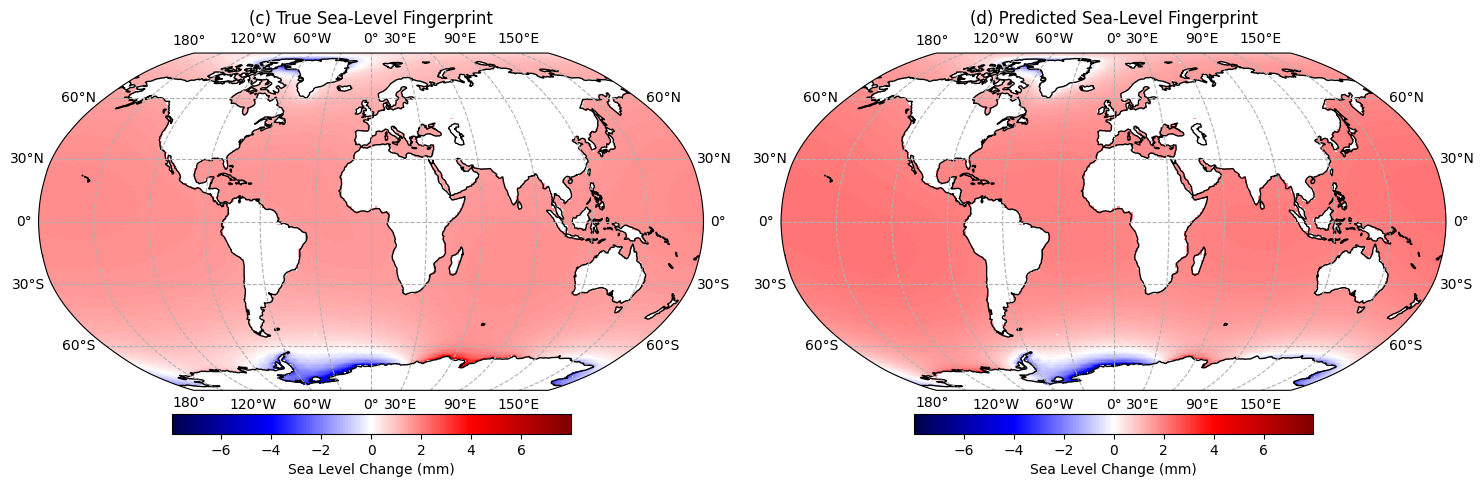

In [ ]:
# --- Calculate sea level fields from both the true and inferred mass changes ---
sea_level_true = model_space_to_sl_operator(model_true)
sea_level_posterior = model_space_to_sl_operator(model_posterior_expectation)

# --- Apply ocean mask for visualization ---
ocean_mask = fp.ocean_projection()

# --- Create a 1x2 subplot layout ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), 
                        subplot_kw={'projection': ccrs.Robinson()})

# --- Prepare the data for each subplot ---
datasets = [sea_level_true * ocean_mask * fp.length_scale * 1000, 
            sea_level_posterior * ocean_mask * fp.length_scale * 1000]

max_abs_sl_change = np.nanmax(
    np.abs(
        np.concatenate([
            datasets[0].data.flatten(),
            datasets[1].data.flatten()
        ])
    )
)

max_abs_sl_change = np.nanmax(
    np.abs(
        np.concatenate([
            [dataset.data.flatten() for dataset in datasets]
        ])
    )
)

titles = ['(c) True Sea-Level Fingerprint', '(d) Predicted Sea-Level Fingerprint']

for i, (dataset, title) in enumerate(zip(datasets, titles)):
    ax = axes[i]
    
    lons, lats = dataset.lons(), dataset.lats()
    kwargs = {'transform': ccrs.PlateCarree(), 'cmap': 'seismic', 
              'vmin': -max_abs_sl_change, 'vmax': max_abs_sl_change}
    
    im = ax.pcolormesh(lons, lats, dataset.data, **kwargs)
    ax.coastlines()
    ax.set_title(title)

    # Tick marks and labels
    lat_interval = kwargs.pop("lat_interval", 30)
    lon_interval = kwargs.pop("lon_interval", 30)
    gl = ax.gridlines(
        linestyle="--",
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
    )
    gl.xlocator = mticker.MultipleLocator(lon_interval)
    gl.ylocator = mticker.MultipleLocator(lat_interval)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    
    # Add colorbar below each subplot
    plt.colorbar(im, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05, 
                 label='Sea Level Change (mm)')

plt.tight_layout()

plt.savefig(FIGURES_DIR / f"4-2_sea_level_estimate.{fig_format}", dpi=300, bbox_inches='tight')

In [ ]:
# --- Set the weighting function for GMSL estimates ---
# Note: the length scale factor dimensionalises the result into mm
GMSL_weighting_function =  -fp.ice_density * fp.one_minus_ocean_function * fp.ice_projection(value=0) * 1000 * fp.length_scale / (fp.water_density * fp.ocean_area)

# --- Form the mapping to GSML ---
B = sl.averaging_operator(model_space, [GMSL_weighting_function])

# --- Get the true GMSL ---
GMSL_true = B(model_true)

# --- Push forward the posterior to the GMSL space ---
GMSL_prior_measure = model_prior_measure.affine_mapping(operator=B)
GMSL_posterior_measure = model_posterior_measure.affine_mapping(operator=B)

# --- Plot the prior and posterior distributions for GMSL ---
fig, ax = plot_1d_distributions(
    GMSL_posterior_measure,
    prior_measures = GMSL_prior_measure,
    true_value = GMSL_true[0],
    xlabel = "GMSL Change (mm)",
    title = "Global Mean Sea Level Change Inference from GRACE Data",
    legend_position = (0.99,0.98)
)

fig.savefig(FIGURES_DIR / f"4-3_GMSL_1D.{fig_format}", dpi=300, bbox_inches='tight')

In a very similar manner, we can estimate a joint measure for the contributions to GMSL change from the Greenland, West Antarctic and East Antarctic ice sheets, with the result displayed using a corner plot:

In [ ]:
# --- Set weighting functions for GMSL contributions ---
GLI_weighting_function = (
    -fp.ice_density
    * fp.one_minus_ocean_function
    * fp.greenland_projection(value=0)
    * 1000 * fp.length_scale
    / (fp.water_density * fp.ocean_area)
)
WAI_weighting_function = (
    -fp.ice_density
    * fp.one_minus_ocean_function
    * fp.west_antarctic_projection(value=0)
    * 1000 * fp.length_scale
    / (fp.water_density * fp.ocean_area)
)
EAI_weighting_function = (
    -fp.ice_density
    * fp.one_minus_ocean_function
    * fp.east_antarctic_projection(value=0)
    * 1000 * fp.length_scale
    / (fp.water_density * fp.ocean_area)
)

# --- Form the mapping to GMSL contributions ---
C = sl.averaging_operator(
    model_space,
    [GLI_weighting_function, WAI_weighting_function, EAI_weighting_function],
)

# --- Push forward the true value and the posterior measure ---
property_true = C(model_true)
property_posterior_measure = model_posterior_measure.affine_mapping(operator=C)

# --- Plot the corner distributions for the GMSL contributions ---
fig, ax = plot_corner_distributions(
    property_posterior_measure,
    true_values=property_true,
    labels=['Greenland Contribution (mm)', 'West Antarctica Contribution (mm)', 'East Antarctica Contribution (mm)'],
    title='Joint Posterior Distributions of GMSL Contributions from Major Ice Sheets'
)

fig.savefig(FIGURES_DIR / f"4-4_GMSL_3D.{fig_format}", dpi=300, bbox_inches='tight')

## Pointwise variance

In [ ]:
# --- Compute the pointwise variance fields for both the ice thickness change and the sea level change ---
# This method estimates the pointwise variance by drawing samples
pointwise_variance = model_posterior_measure.sample_pointwise_variance(40)
pointwise_variance_sl = model_posterior_measure.affine_mapping(operator=model_space_to_sl_operator).sample_pointwise_variance(40)

# --- Convert to standard deviation for plotting ---
pointwise_std = pointwise_variance.copy()
pointwise_std_sl = pointwise_variance_sl.copy()
pointwise_std.data = np.sqrt(pointwise_variance.data)
pointwise_std_sl.data = np.sqrt(pointwise_variance_sl.data)

In [ ]:
# --- Create the figure ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), 
                        subplot_kw={'projection': ccrs.Robinson()})

data_ice = fp.ice_projection() * pointwise_std * fp.length_scale
data_sl = fp.ocean_projection() * pointwise_std_sl * fp.length_scale * 1000

datasets = [data_ice, data_sl]
titles = ['(a) Pointwise standard deviation (Ice)', '(b) Pointwise standard deviation (Sea Level)']
vmaxs = [0.08, 1.75]

for i, (dataset, title, vmax) in enumerate(zip(datasets, titles, vmaxs)):
    ax = axes[i]
    
    lons, lats = dataset.lons(), dataset.lats()
    kwargs = {'transform': ccrs.PlateCarree(), 'cmap': 'cmo.thermal', 
              'vmin': 0, 'vmax': vmax}
    
    im = ax.pcolormesh(lons, lats, dataset.data, **kwargs)
    ax.coastlines()
    ax.set_title(title)

    # Tick marks and labels
    lat_interval = kwargs.pop("lat_interval", 30)
    lon_interval = kwargs.pop("lon_interval", 30)
    gl = ax.gridlines(
        linestyle="--",
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
    )
    gl.xlocator = mticker.MultipleLocator(lon_interval)
    gl.ylocator = mticker.MultipleLocator(lat_interval)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    
    # Add colorbar below each subplot
    plt.colorbar(im, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05, label=['Ice thickness (m)','Sea level (mm)'][i])

plt.tight_layout()

plt.savefig(FIGURES_DIR / f"4-5_pointwise_std.{fig_format}", dpi=300, bbox_inches='tight')

## A comparison of different discretisations of the model space

In [ ]:
# --- Set up the Bayesian inversion ---
bayesian_inversion_precon = inf.LinearBayesianInversion(forward_problem_precon, model_prior_measure_precon)

# --- Solve for the posterior distribution ---
print("Solving the linear system...")
model_posterior_measure_precon = bayesian_inversion_precon.model_posterior_measure(
    data, inf.EigenSolver(parallel=True, n_jobs=40),
)

# --- Get the posterior expectation ---
model_posterior_expectation_precon = model_posterior_measure_precon.expectation

In [ ]:
# --- Plot maps of the posterior means in the higher and lower dimensional spaces ---
max_abs_ice_change = np.nanmax(
    np.abs(
        np.concatenate([
            (model_posterior_expectation).data.flatten(),
            (model_posterior_expectation_precon).data.flatten()
        ])
    )
) * fp.length_scale

# --- Create a 1x2 subplot layout ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), 
                        subplot_kw={'projection': ccrs.Robinson()})

# --- Prepare the data for each subplot ---
datasets = [model_posterior_expectation * fp.length_scale, model_posterior_expectation_precon * fp.length_scale]
titles = ['(a) Posterior Expectation (Higher Dimensional)', '(b) Posterior Expectation (Lower Dimensional)']

for i, (data, title) in enumerate(zip(datasets, titles)):
    ax = axes[i]
    
    lons, lats = data.lons(), data.lats()
    kwargs = {'transform': ccrs.PlateCarree(), 'cmap': 'seismic', 
              'vmin': -max_abs_ice_change, 'vmax': max_abs_ice_change}
    
    im = ax.pcolormesh(lons, lats, data.data, **kwargs)
    ax.coastlines()
    ax.set_title(title)

    # Tick marks and labels
    lat_interval = kwargs.pop("lat_interval", 30)
    lon_interval = kwargs.pop("lon_interval", 30)
    gl = ax.gridlines(
        linestyle="--",
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
    )
    gl.xlocator = mticker.MultipleLocator(lon_interval)
    gl.ylocator = mticker.MultipleLocator(lat_interval)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    
    # Add colorbar below each subplot
    plt.colorbar(im, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05, 
                 label='Ice Thickness Change (m)')

plt.tight_layout()

plt.savefig(FIGURES_DIR / f"4-6_discretisation_comparison.{fig_format}", dpi=300, bbox_inches='tight')